# Student Dropout Prediction - Education Analytics
#### Objective: 
The main goal of this project is to construct a robust end-to-end data pipeline to predict student dropout risk. By identifying vulnerable students early using demographic, socioeconomic, and academic indicators, academic institutions can execute strategic interventions. The outcomes are exported into structured datasets optimized for downstream interactive dashboards in Power BI.

## 1. Libraries & Data Collection

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv('student_dropout_dataset.csv')
print("--- Dataset Initial Look ---")
print(df.info())

--- Dataset Initial Look ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   100

## 2. Data Cleaning & Preprocessing

In [2]:
# Define feature lists dynamically
numeric_features = ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 
                    'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']
categorical_features = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']

# Handle Missing Data and Preprocessing via automated scikit-learn Pipelines
# Median imputation for numeric features (resilient to outliers)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Most Frequent imputation for categorical features, followed by One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Bundle preprocessing into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 3. EDA - Exploratory Data Analysis

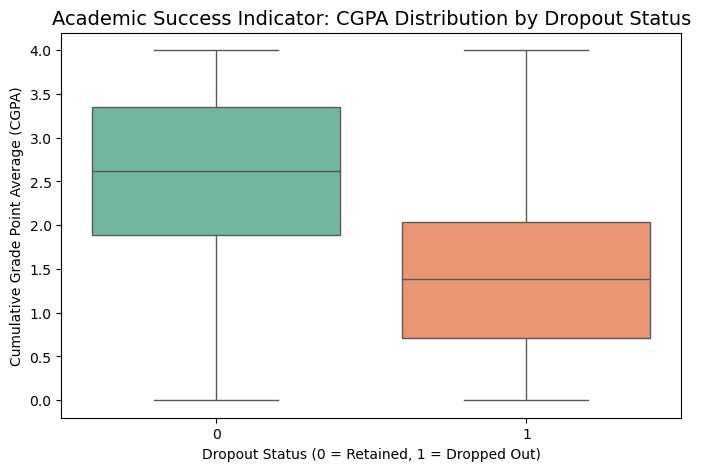

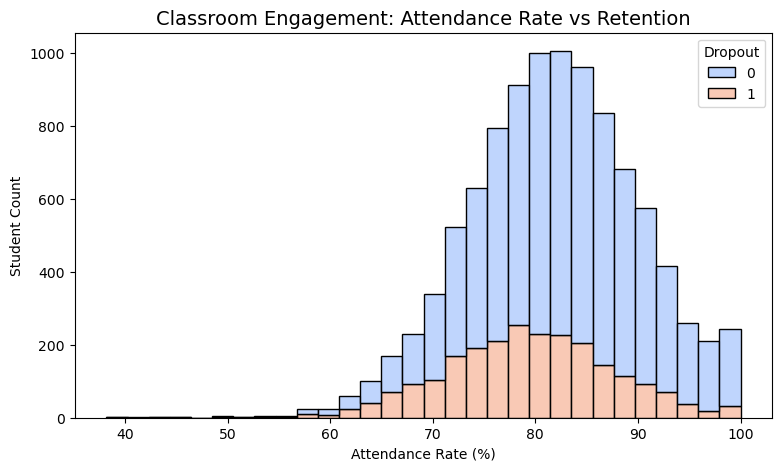

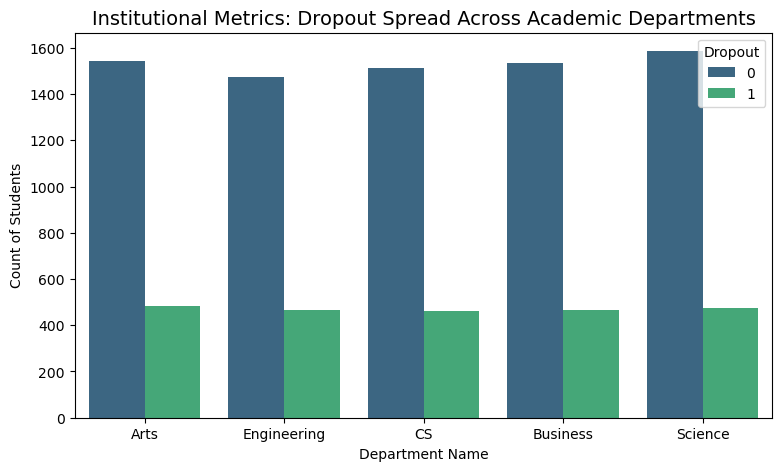

In [3]:
# Set visualization parameters
# sns.set_theme(style="whitegrid")
# plt.rcParams['figure.figsize'] = (10, 6)

# Visualization 1: Academic Performance Impact (CGPA vs Dropout)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dropout', y='CGPA', data=df, palette='Set2', hue='Dropout', legend=False)
plt.title('Academic Success Indicator: CGPA Distribution by Dropout Status', fontsize=14)
plt.xlabel('Dropout Status (0 = Retained, 1 = Dropped Out)')
plt.ylabel('Cumulative Grade Point Average (CGPA)')
plt.savefig('eda_cgpa_vs_dropout.png', dpi=300)
plt.show()
#plt.close()

#Visualization 2: Behavioral Patterns (Attendance Rate)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Attendance_Rate', hue='Dropout', multiple='stack', bins=30, palette='coolwarm')
plt.title('Classroom Engagement: Attendance Rate vs Retention', fontsize=14)
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Student Count')
plt.savefig('eda_attendance_vs_dropout.png', dpi=300)
plt.show()
# plt.close()

# # Visualization 3: Department Breakdown
plt.figure(figsize=(9, 5))
sns.countplot(x='Department', hue='Dropout', data=df, palette='viridis')
plt.title('Institutional Metrics: Dropout Spread Across Academic Departments', fontsize=14)
plt.xlabel('Department Name')
plt.ylabel('Count of Students')
plt.savefig('eda_department_vs_dropout.png', dpi=300)
plt.show()
# plt.close()

## 4. Model Building

In [4]:
X = df[numeric_features + categorical_features]
y = df['Dropout']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Instantiate a suite of foundational classification models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}
# Evaluate models iteratively
print("\n--- Model Training & Comparative Evaluation ---")
for model_name, model_obj in models.items():
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', model_obj)])
    
    # Train model
    full_pipeline.fit(X_train, y_train)
    # Generate predictions
    y_pred = full_pipeline.predict(X_test)
    y_proba = full_pipeline.predict_proba(X_test)[:, 1]
    print(f"\n==================== {model_name} ====================")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))


--- Model Training & Comparative Evaluation ---

==================== Logistic Regression ====================
Accuracy Score: 0.8155
ROC AUC Score: 0.8206

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.68      0.40      0.51       471

    accuracy                           0.82      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.80      0.82      0.80      2000

Confusion Matrix:
 [[1441   88]
 [ 281  190]]

==================== Random Forest ====================
Accuracy Score: 0.8045
ROC AUC Score: 0.8004

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1529
           1       0.64      0.38      0.48       471

    accuracy                           0.80      2000
   macro avg       0.74      0.66      0.68      2000
weighted avg       0.79      0

C:\Users\DELL\AppData\Local\Temp\ipykernel_9824\1610835433.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=metrics, palette="rocket")


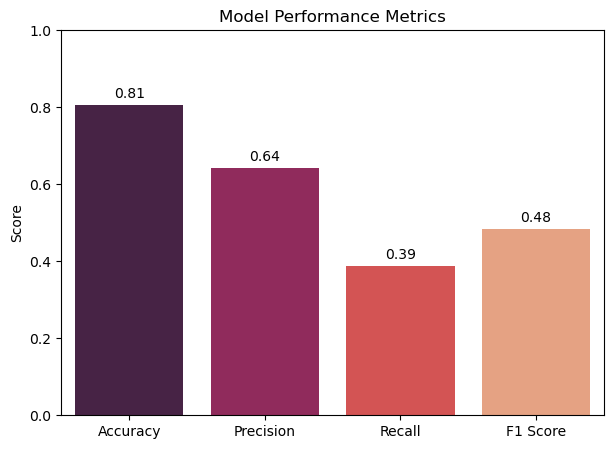

In [13]:
# acc = accuracy_score(y_test,y_pred)
# prec = precision_score(y_test,y_pred)
# rec = recall_score(y_test,y_pred)
# f1 = f1_score(y_test,y_pred)

# metrics = [acc,prec,rec,f1]
# labels = ['Accuracy','Precision','Recall','f1 Score']

# plt.figure(figsize=(7,5))
# sns.barplot(x=labels,y=metrics,palette="rocket")
# plt.ylim(0,1)
# plt.title("Model Performance Metrics")
# plt.ylabel("Score")
# plt.bar_label(bars, padding=3)
# plt.show()


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = [acc, prec, rec, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(7, 5))

# 1. Create the plot (assigned to ax)
ax = sns.barplot(x=labels, y=metrics, palette="rocket")

plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.ylabel("Score")

# 2. Reference the bar containers and format to 2 decimal places
for container in ax.containers:
    plt.bar_label(container, fmt='%.2f', padding=3)

plt.show()


## 5. Exploring Final Outputs for PowerBI

In [5]:
# Use the production-grade Random Forest model to calculate risk probabilities for the entire dataset
best_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                      ('classifier', RandomForestClassifier(n_estimators=150, random_state=42))])
best_model_pipeline.fit(X, y)

# Assign Dropout Risk Score and Level back to the primary dataset
df['Dropout_Probability'] = best_model_pipeline.predict_proba(X)[:, 1]
df['Risk_Level'] = pd.cut(df['Dropout_Probability'], 
                          bins=[0, 0.3, 0.6, 1.0], 
                          labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Save the enriched data back to CSV for immediate import into Power BI
df.to_csv('enriched_student_dropout_data.csv', index=False)
print("\n[Success] Enriched dataset saved as 'enriched_student_dropout_data.csv' for Power BI integration!")


[Success] Enriched dataset saved as 'enriched_student_dropout_data.csv' for Power BI integration!
